# **Step 1: Install the required packages**

In [1]:
!pip install numpy pandas scikit-learn matplotlib scipy

# **Step 2: Generating the QSAR model**

## **a. Generate synthetic QSAR data**

In [2]:
mport numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [3]:
# Step 1: Generate Synthetic QSAR Dataset
np.random.seed(42)
n_samples = 1000 # Number of synthetic compounds

In [7]:
# Generate random logP and molecular weight values
logP = np.random.uniform(1, 5, n_samples) # logP values between 1 and 5
molecular_weight = np.random.uniform(200, 600, n_samples) # Molecular weight between 200 and 600 g/mol

In [8]:
# Generate synthetic elimination rate constants (kel) based on a simple function
kel = 0.01 + 0.001 * logP -0.00005 * molecular_weight + np.random.normal(0, 0.001, n_samples)

In [9]:
# Apply a lower bound to ensure all kel values are positive
kel = np.maximum(kel, 0.001) # Set any kel <= 0 to 0.001

In [10]:
# Create a DataFrame for the synthetic dataset
qsar_data = pd.DataFrame({
'logP': logP,
'molecular_weight': molecular_weight,
'kel': kel # Elimination rate constant
})

In [11]:
# Show first few rows of the dataset
print(qsar_data.head())

       logP  molecular_weight    kel
0  2.498160        274.053172  0.001
1  4.802857        416.760379  0.001
2  3.927976        549.178334  0.001
3  3.394634        492.889955  0.001
4  1.624075        522.624459  0.001


## **b. Train the QSAR model**

In [12]:
# Step 2: Split the dataset into training and testing sets
X = qsar_data[['logP', 'molecular_weight']]
y = qsar_data['kel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Step 3: Train a Random Forest Regressor
qsar_model = RandomForestRegressor(n_estimators=100, random_state=42)
qsar_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
# Step 4: Predict on the test set and evaluate the model
y_pred = qsar_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"QSAR Model Test MSE: {mse:.4f}")

QSAR Model Test MSE: 0.0000


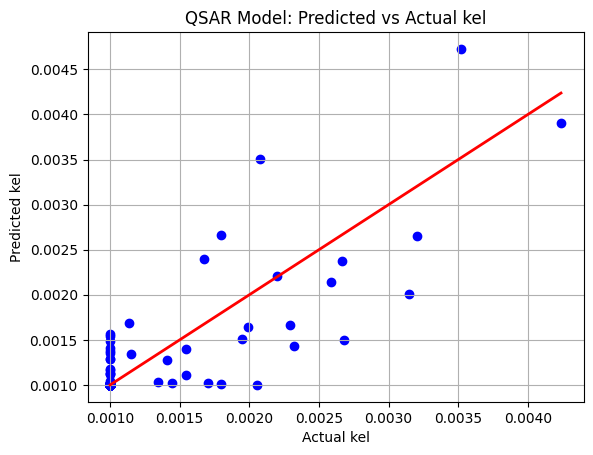

In [16]:
# Plot predicted vs actual kel values
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual kel')
plt.ylabel('Predicted kel')
plt.title('QSAR Model: Predicted vs Actual kel')
plt.grid(True)
plt.show()

# **Step 3: Simulating the PBPK model**

## **a. Define the PBPK model**

In [17]:
from scipy.integrate import solve_ivp

In [19]:
# Step 1: Define PBPK model equations
def pbpk_model(t, y, kel, k12, k21, k13, k31):
 C1, C2, C3 = y # Concentrations in the three compartments
 dC1_dt = -(kel + k12 + k13) * C1 + k21 * C2 + k31 * C3 # Central compartment
 dC2_dt = k12 * C1 -k21 * C2 # Peripheral compartment 1
 dC3_dt = k13 * C1 -k31 * C3 # Peripheral compartment 2
 return [dC1_dt, dC2_dt, dC3_dt]

In [21]:
# Step 2: Parameters for compartment transfer rates (assumed values)
k12, k21, k13, k31 = 0.05, 0.03, 0.04, 0.02 # Transfer rates

In [23]:
# Step 3: Initial dose and conditions
dose = 100 # Initial dose in mg
initial_conditions = [dose, 0, 0] # All drug is initially in the central compartment

In [24]:
# Step 4: Simulate PBPK model using solve_ivp
time_points_sim = np.linspace(0, 48, 500) # Time points for simulation (0 to 48 hours)

In [27]:
# Predict kel using the trained QSAR model
new_compound_descriptors = pd.DataFrame([{'logP': 3.5, 'molecular_weight': 450}])
kel_predicted = qsar_model.predict(new_compound_descriptors)[0]

In [28]:
# Solve the PBPK model
sol = solve_ivp(pbpk_model, [0, 48], initial_conditions,
t_eval=time_points_sim, args=(kel_predicted, k12, k21, k13, k31))

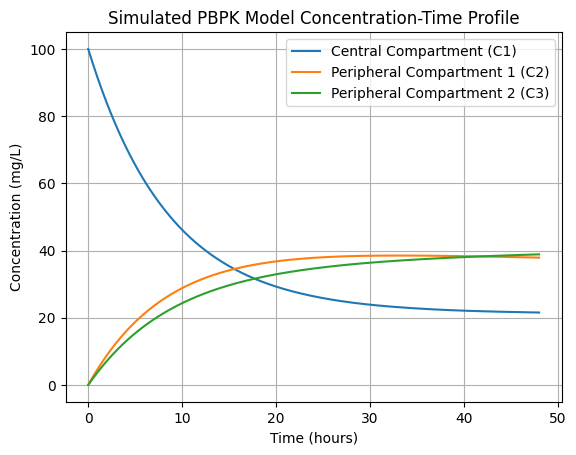

In [29]:
# Step 5: Plot the simulated concentration-time profile
plt.plot(time_points_sim, sol.y[0], label='Central Compartment (C1)')
plt.plot(time_points_sim, sol.y[1], label='Peripheral Compartment 1 (C2)')
plt.plot(time_points_sim, sol.y[2], label='Peripheral Compartment 2 (C3)')
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mg/L)')
plt.title('Simulated PBPK Model Concentration-Time Profile')
plt.grid(True)
plt.legend()
plt.show()